# Task 1.3 — Math for ML Practice Set
Worked problems in **statistics, probability, linear algebra, and calculus** as they show up in ML algorithms.
**Skill Set Go EduTech — AI/ML Internship, Week 1**

## 1. Statistics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as spstats

# Sample: exam scores of 15 students (a small real-world-style dataset)
scores = np.array([62, 74, 74, 68, 90, 55, 81, 74, 95, 60, 71, 83, 68, 77, 64])
print("Data:", scores)

Data: [62 74 74 68 90 55 81 74 95 60 71 83 68 77 64]


### 1.1 Central tendency
Compute mean, median, and mode by hand (formula), then verify with NumPy/SciPy.

In [2]:
n = len(scores)
mean_manual = sum(scores) / n
sorted_scores = np.sort(scores)
median_manual = sorted_scores[n // 2] if n % 2 == 1 else (sorted_scores[n//2 - 1] + sorted_scores[n//2]) / 2
mode_manual = spstats.mode(scores, keepdims=True)

print(f"Mean   (manual):  {mean_manual:.2f}  | NumPy: {np.mean(scores):.2f}")
print(f"Median (manual):  {median_manual:.2f}  | NumPy: {np.median(scores):.2f}")
print(f"Mode:             {mode_manual.mode[0]} (appears {mode_manual.count[0]} times)")

Mean   (manual):  73.07  | NumPy: 73.07
Median (manual):  74.00  | NumPy: 74.00
Mode:             74 (appears 3 times)


### 1.2 Dispersion
Variance and standard deviation — the core quantities behind feature scaling
(standardization: `(x - mean) / std`) used before training most ML models.

In [3]:
# Population variance, by formula: sum((x - mean)^2) / n
variance_manual = sum((x - mean_manual) ** 2 for x in scores) / n
std_manual = variance_manual ** 0.5

print(f"Variance (manual): {variance_manual:.2f}  | NumPy: {np.var(scores):.2f}")
print(f"Std Dev  (manual): {std_manual:.2f}  | NumPy: {np.std(scores):.2f}")

# Standardized (z-score) version of the data — this is what StandardScaler does in scikit-learn
z_scores = (scores - mean_manual) / std_manual
print("\nZ-scores:", np.round(z_scores, 2))
print("Standardized mean ~ 0:", round(z_scores.mean(), 6), "| Standardized std ~ 1:", round(z_scores.std(), 6))

Variance (manual): 113.66  | NumPy: 113.66
Std Dev  (manual): 10.66  | NumPy: 10.66

Z-scores: [-1.04  0.09  0.09 -0.48  1.59 -1.69  0.74  0.09  2.06 -1.23 -0.19  0.93
 -0.48  0.37 -0.85]
Standardized mean ~ 0: 0.0 | Standardized std ~ 1: 1.0


### 1.3 Quartiles & IQR-based outlier detection
This is the same rule used for the boxplots in the Task 1.2 EDA.

In [4]:
q1, q2, q3 = np.percentile(scores, [25, 50, 75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = scores[(scores < lower_fence) | (scores > upper_fence)]

print(f"Q1={q1}, Q2 (median)={q2}, Q3={q3}, IQR={iqr}")
print(f"Outlier fences: [{lower_fence}, {upper_fence}]")
print("Outliers found:", outliers if len(outliers) else "none")

Q1=66.0, Q2 (median)=74.0, Q3=79.0, IQR=13.0
Outlier fences: [46.5, 98.5]
Outliers found: none


## 2. Probability

### 2.1 Conditional probability & Bayes' theorem
Using the cleaned Titanic dataset from Task 1.2: what's the probability a
passenger survived, given that they were female? This is exactly the kind
of conditional reasoning a Naive Bayes classifier automates.

In [5]:
import pandas as pd
df = pd.read_csv('data/titanic_cleaned.csv')

total = len(df)
p_female = (df['Sex'] == 'female').mean()
p_survived = df['Survived'].mean()
p_female_and_survived = ((df['Sex'] == 'female') & (df['Survived'] == 1)).mean()

# P(Survived | Female) = P(Female and Survived) / P(Female)
p_survived_given_female = p_female_and_survived / p_female

print(f"P(Female)            = {p_female:.3f}")
print(f"P(Survived)           = {p_survived:.3f}")
print(f"P(Female ∩ Survived)  = {p_female_and_survived:.3f}")
print(f"P(Survived | Female)  = {p_survived_given_female:.3f}")

P(Female)            = 0.352
P(Survived)           = 0.384
P(Female ∩ Survived)  = 0.262
P(Survived | Female)  = 0.742


In [6]:
# Verify the same number using Bayes' theorem directly:
# P(Survived | Female) = P(Female | Survived) * P(Survived) / P(Female)
p_female_given_survived = df[df['Survived'] == 1]['Sex'].eq('female').mean()
bayes_result = (p_female_given_survived * p_survived) / p_female

print(f"P(Female | Survived) = {p_female_given_survived:.3f}")
print(f"Bayes' theorem result: {bayes_result:.3f}  (matches direct calculation above)")

P(Female | Survived) = 0.681
Bayes' theorem result: 0.742  (matches direct calculation above)


### 2.2 Normal distribution
The normal distribution underlies many ML assumptions (e.g. Gaussian Naive
Bayes, residual assumptions in linear regression). Below: PDF of the cleaned
`Age` column vs. a fitted normal curve.

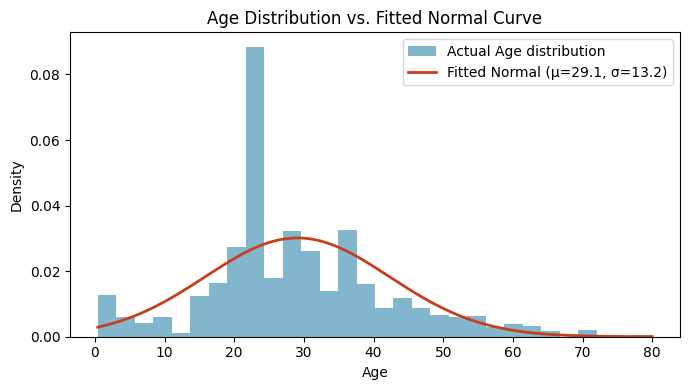

P(20 <= Age <= 30) under fitted normal ≈ 0.281


In [7]:
age = df['Age'].values
mu, sigma = age.mean(), age.std()

x = np.linspace(age.min(), age.max(), 200)
pdf = spstats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(7, 4))
plt.hist(age, bins=30, density=True, alpha=0.6, color='#2E86AB', label='Actual Age distribution')
plt.plot(x, pdf, color='#C73E1D', linewidth=2, label=f'Fitted Normal (μ={mu:.1f}, σ={sigma:.1f})')
plt.title('Age Distribution vs. Fitted Normal Curve')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('normal_distribution_fit.png', dpi=100)
plt.show()

# Example: probability a random passenger is between 20 and 30 years old, using the normal approximation
p_20_30 = spstats.norm.cdf(30, mu, sigma) - spstats.norm.cdf(20, mu, sigma)
print(f"P(20 <= Age <= 30) under fitted normal ≈ {p_20_30:.3f}")

## 3. Linear Algebra

### 3.1 Vectors — dot product & cosine similarity
Cosine similarity (built from the dot product) is the standard way ML
compares feature vectors, embeddings, and documents.

In [8]:
v1 = np.array([2, 4, 1, 8])
v2 = np.array([3, 1, 5, 6])

dot_manual = sum(a * b for a, b in zip(v1, v2))
dot_numpy = np.dot(v1, v2)

norm_v1 = (sum(a**2 for a in v1)) ** 0.5
norm_v2 = (sum(b**2 for b in v2)) ** 0.5
cosine_sim = dot_manual / (norm_v1 * norm_v2)

print(f"v1 . v2 (manual) = {dot_manual}  | NumPy: {dot_numpy}")
print(f"||v1|| = {norm_v1:.3f}, ||v2|| = {norm_v2:.3f}")
print(f"Cosine similarity = {cosine_sim:.3f}")

v1 . v2 (manual) = 63  | NumPy: 63
||v1|| = 9.220, ||v2|| = 8.426
Cosine similarity = 0.811


### 3.2 Matrix operations
Multiplication, transpose, determinant, inverse — the operations behind the
Normal Equation for linear regression: `w = (XᵀX)⁻¹ Xᵀy`.

In [9]:
A = np.array([[2, 1], [1, 3]])
B = np.array([[4, 0], [2, 5]])

print("A =\n", A)
print("B =\n", B)
print("\nA @ B (matrix multiplication) =\n", A @ B)
print("\nA transpose =\n", A.T)
print("\ndet(A) =", np.linalg.det(A))
print("\nA inverse =\n", np.linalg.inv(A))
print("\nA @ A_inverse (should be identity) =\n", np.round(A @ np.linalg.inv(A), 6))

A =
 [[2 1]
 [1 3]]
B =
 [[4 0]
 [2 5]]

A @ B (matrix multiplication) =
 [[10  5]
 [10 15]]

A transpose =
 [[2 1]
 [1 3]]

det(A) = 5.000000000000001

A inverse =
 [[ 0.6 -0.2]
 [-0.2  0.4]]

A @ A_inverse (should be identity) =
 [[ 1.  0.]
 [-0.  1.]]


### 3.3 The Normal Equation — solving linear regression with linear algebra
Given `X` (features + bias column) and `y` (target), solve for weights
directly, without gradient descent, and confirm it matches scikit-learn.

In [10]:
from sklearn.linear_model import LinearRegression

# Small synthetic dataset: y = 3x + 5 + noise
rng = np.random.default_rng(42)
X_raw = np.linspace(0, 10, 20)
y = 3 * X_raw + 5 + rng.normal(0, 1, size=20)

# Add bias column of 1s -> X becomes [1, x]
X = np.column_stack([np.ones_like(X_raw), X_raw])

# Normal equation: w = (X^T X)^-1 X^T y
w = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"Normal equation solution: intercept={w[0]:.3f}, slope={w[1]:.3f}")

# Verify against scikit-learn
lr = LinearRegression().fit(X_raw.reshape(-1, 1), y)
print(f"scikit-learn solution:    intercept={lr.intercept_:.3f}, slope={lr.coef_[0]:.3f}")

Normal equation solution: intercept=4.726, slope=3.048
scikit-learn solution:    intercept=4.726, slope=3.048


## 4. Calculus

### 4.1 Derivatives & the chain rule (symbolic, via SymPy)
Derivatives are how every neural network learns — backpropagation is
repeated application of the chain rule.

In [11]:
import sympy as sp

x = sp.symbols('x')

f = x**3 - 4*x**2 + 2*x
f_prime = sp.diff(f, x)
print("f(x)  =", f)
print("f'(x) =", f_prime)
print("f'(2) =", f_prime.subs(x, 2))

# Chain rule example: g(x) = (3x + 1)^4  ->  used constantly when differentiating
# a loss function composed with a model's output
g = (3*x + 1)**4
g_prime = sp.diff(g, x)
print("\ng(x)  =", g)
print("g'(x) =", g_prime, " (chain rule applied automatically)")

f(x)  = x**3 - 4*x**2 + 2*x
f'(x) = 3*x**2 - 8*x + 2
f'(2) = -2

g(x)  = (3*x + 1)**4
g'(x) = 12*(3*x + 1)**3  (chain rule applied automatically)


### 4.2 Partial derivatives & the gradient
For Mean Squared Error `L(m, b) = (1/n) * sum((m*x + b - y)^2)`, the
gradient (∂L/∂m, ∂L/∂b) tells gradient descent which direction reduces
the loss.

In [12]:
m, b, xi, yi = sp.symbols('m b x_i y_i')

loss_term = (m * xi + b - yi) ** 2
dL_dm = sp.diff(loss_term, m)
dL_db = sp.diff(loss_term, b)

print("Loss term (per point):", loss_term)
print("∂L/∂m =", dL_dm)
print("∂L/∂b =", dL_db)

Loss term (per point): (b + m*x_i - y_i)**2
∂L/∂m = 2*x_i*(b + m*x_i - y_i)
∂L/∂b = 2*b + 2*m*x_i - 2*y_i


### 4.3 Gradient descent from scratch
Using the partial derivatives above to iteratively fit the same line as the
Normal Equation in section 3.3 — this is literally how libraries like
PyTorch/TensorFlow train models under the hood.

Gradient descent solution: intercept=4.705, slope=3.051
Normal equation solution:  intercept=4.726, slope=3.048
-> Both methods converge to essentially the same line.


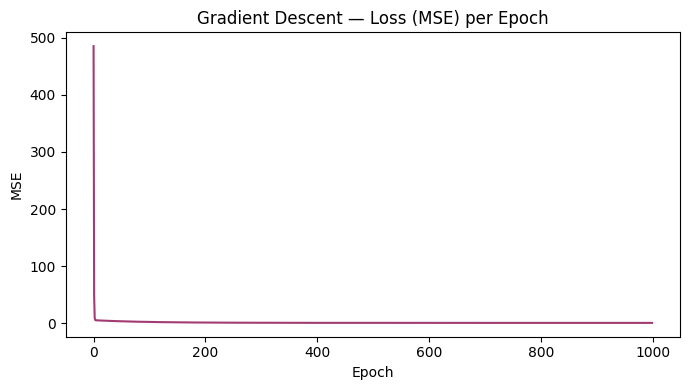

In [13]:
def gradient_descent(X_raw, y, lr=0.01, epochs=1000):
    m, b = 0.0, 0.0
    n = len(X_raw)
    history = []
    for _ in range(epochs):
        y_pred = m * X_raw + b
        error = y_pred - y
        dm = (2 / n) * np.dot(error, X_raw)
        db = (2 / n) * np.sum(error)
        m -= lr * dm
        b -= lr * db
        mse = np.mean(error ** 2)
        history.append(mse)
    return m, b, history

m_gd, b_gd, loss_history = gradient_descent(X_raw, y, lr=0.01, epochs=1000)
print(f"Gradient descent solution: intercept={b_gd:.3f}, slope={m_gd:.3f}")
print(f"Normal equation solution:  intercept={w[0]:.3f}, slope={w[1]:.3f}")
print("-> Both methods converge to essentially the same line.")

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='#A23B72')
plt.title('Gradient Descent — Loss (MSE) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig('gradient_descent_convergence.png', dpi=100)
plt.show()

## 5. Summary
- **Statistics** — mean/median/mode/variance/std underlie feature scaling; IQR underlies outlier detection (used directly in Task 1.2).
- **Probability** — conditional probability and Bayes' theorem are the basis of Naive Bayes classifiers; the normal distribution underlies Gaussian assumptions in several models.
- **Linear algebra** — dot products drive similarity/embeddings; the Normal Equation solves linear regression exactly using matrix inversion.
- **Calculus** — derivatives and the chain rule are the mechanics of backpropagation; gradient descent (built from partial derivatives) is confirmed here to converge to the same solution as the closed-form Normal Equation.